# 01 — Preparación del Dataset v2.0

Clasificación multi-label de patologías en radiografías de tórax.
**Datasets**: ChestXray8 (NIH) · CheXpert (Stanford) · VinBigData (Kaggle)

Este notebook cubre:
- **(a)** Carga y organización del dataset — clase `Dataset` y `DataLoader` por fuente → unificado
- **(b)** Particionado train / val / test — criterio, distribución, leakage check
- **(c)** Preprocesamiento — resize, normalización, conversión de canales
- **(d)** Data augmentation — transforms de train con justificación + visualización
- **(e)** Verificación final del batch

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from PIL import Image

# Semilla global para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_ROOT = os.path.abspath(os.path.join(".."))
DATA_DIR     = os.path.join(DATASET_ROOT, "data")

CANONICAL_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Pleural_Effusion", "Pneumonia", "Pneumothorax",
    "Infiltration", "Nodule_Mass", "Pleural_Thickening", "No_Finding",
]
NUM_CLASSES = len(CANONICAL_LABELS)

print(f"PyTorch:      {torch.__version__}")
print(f"torchvision:  {torchvision.__version__}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"{NUM_CLASSES} clases canónicas: {CANONICAL_LABELS}")
assert os.path.exists(DATA_DIR), f"No se encuentra data/: {DATA_DIR}"


PyTorch:      2.12.0+cpu
torchvision:  0.27.0+cpu
Dataset root: e:\dataset
Data dir:     e:\dataset\data
11 clases canónicas: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural_Effusion', 'Pneumonia', 'Pneumothorax', 'Infiltration', 'Nodule_Mass', 'Pleural_Thickening', 'No_Finding']


---
## (a) Carga y organización del dataset

### Estructura de carpetas

```
dataset/
├── ChestXray8/
│   ├── Data_Entry_2017.csv       ← metadata + labels (pipe-separated)
│   ├── train_val_list.txt / test_list.txt
│   └── images_001/ … images_012/images/*.png   ← 112 120 radiografías
├── chexpert/
│   ├── train.csv                 ← 223 414 imágenes, labels multi-col (0/1/-1/NaN)
│   └── train/*.jpg               ← rutas aplanadas (patient_study_view.jpg)
├── VinBigData/
│   ├── train.csv                 ← 67 914 filas (row-per-finding, multi-radiólogo)
│   └── train/*.jpg               ← 15 000 imágenes
└── data/
    ├── train.csv                 ← CSV unificado: 264 275 imágenes (CX8 + CheXpert)
    ├── val.csv                   ← 45 663 imágenes
    ├── test_interno.csv          ← 25 596 (ChestXray8 test oficial)
    └── test_externo.csv          ← 15 000 (VinBigData, generalización externa)
```

### Por qué no `ImageFolder`

`ImageFolder` de torchvision asume **una clase por imagen** en subdirectorios separados. Nuestras radiografías son **multi-label** (una imagen puede tener Atelectasis y Pleural_Effusion simultáneamente), por lo que se requiere una clase `Dataset` personalizada que maneje el vector de 11 labels.

In [2]:
class ChestXRayDataset(Dataset):
    """Dataset unificado de rayos X de tórax.

    Acepta tanto una ruta a CSV como un DataFrame de pandas pre-filtrado.
    Eso permite crear subsets por fuente (source=='chestxray8') sin duplicar código.
    """

    def __init__(self, source, root_dir, labels=CANONICAL_LABELS,
                 transform=None, nan_fill=0.0):
        if isinstance(source, pd.DataFrame):
            self.df = source.reset_index(drop=True)
        else:
            self.df = pd.read_csv(source, low_memory=False)
        self.root_dir  = root_dir
        self.labels    = labels
        self.transform = transform
        self.nan_fill  = nan_fill

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        # Convertir a RGB: las radiografías son grayscale pero los modelos
        # preentrenados (ResNet, DenseNet) esperan 3 canales
        img      = Image.open(img_path).convert("RGB")
        label_vals = row[self.labels].fillna(self.nan_fill).values.astype("float32")
        labels   = torch.tensor(label_vals)
        if self.transform:
            img = self.transform(img)
        return img, labels

print("Clase ChestXRayDataset definida.")

Clase ChestXRayDataset definida.


### Un DataLoader por fuente

Los CSVs unificados en `data/` incluyen la columna `source` (`chestxray8` / `chexpert` / `vinbigdata`).
Filtrando por esta columna obtenemos datasets independientes por fuente, con la misma interfaz.

In [ ]:
BATCH_SIZE  = 32

# ── Cargar CSVs unificados ──────────────────────────────────────────────────
train_df    = pd.read_csv(os.path.join(DATA_DIR, "train.csv"),        low_memory=False)
test_ext_df = pd.read_csv(os.path.join(DATA_DIR, "test_externo.csv"), low_memory=False)

# ── Datasets por fuente ─────────────────────────────────────────────────────
cx8_train_ds  = ChestXRayDataset(
    train_df[train_df["source"] == "chestxray8"], DATASET_ROOT)
chex_train_ds = ChestXRayDataset(
    train_df[train_df["source"] == "chexpert"],   DATASET_ROOT)
vin_test_ds   = ChestXRayDataset(
    test_ext_df,                                  DATASET_ROOT)

# ── Un DataLoader por fuente ────────────────────────────────────────────────
cx8_loader  = DataLoader(cx8_train_ds,  batch_size=BATCH_SIZE, shuffle=True)
chex_loader = DataLoader(chex_train_ds, batch_size=BATCH_SIZE, shuffle=True)
vin_loader  = DataLoader(vin_test_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"{'Fuente':<20}  {'Dataset'}     {'Batches'}")
print("-" * 55)
print(f"{'ChestXray8 (train)':<20}  {len(cx8_train_ds):>10,}  {len(cx8_loader):>8,}")
print(f"{'CheXpert (train)':<20}  {len(chex_train_ds):>10,}  {len(chex_loader):>8,}")
print(f"{'VinBigData (test ext)':<20}  {len(vin_test_ds):>10,}  {len(vin_loader):>8,}")

Fuente                Dataset     Batches
-------------------------------------------------------
ChestXray8 (train)        73,916     2,310
CheXpert (train)         190,359     5,949
VinBigData (test ext)      15,000       469


### Unificación con `ConcatDataset`

`ConcatDataset` encadena múltiples datasets sin copiar datos. El DataLoader unificado accede a todos los ejemplos de train (ChestXray8 + CheXpert) con shuffle global.

In [ ]:
# ── Dataset y DataLoader unificados ────────────────────────────────────────
unified_train_ds     = ConcatDataset([cx8_train_ds, chex_train_ds])
unified_train_loader = DataLoader(
    unified_train_ds,
    batch_size=BATCH_SIZE, shuffle=True, pin_memory=True,
)

print(f"Unified train:  {len(unified_train_ds):,} imágenes  |  {len(unified_train_loader):,} batches")

# Verificar una muestra individual (sin transforms → img es PIL Image, no tensor)
# Los shapes de tensor se verifican en la sección (e) con train_loader
sample_img, sample_lbl = cx8_train_ds[0]
print(f"\nMuestra individual (sin transforms):")
print(f"  img  → {type(sample_img).__name__}, size={sample_img.size} (W×H)")
print(f"  labels → tensor shape={sample_lbl.shape}, dtype={sample_lbl.dtype}")

Unified train:  264,275 imágenes  |  8,259 batches

Muestra individual (sin transforms):
  img  → Image, size=(1024, 1024) (W×H)
  labels → tensor shape=torch.Size([11]), dtype=torch.float32


---
## (b) Particionado

### Criterio de partición

| Dataset | Estrategia | Variable de split |
|---|---|---|
| **ChestXray8** | Split **oficial NIH** (`train_val_list.txt` / `test_list.txt`) → subdivisión 85/15 por paciente | `patient_id` |
| **CheXpert** | Split aleatorio estratificado **85 % train / 15 % val** | `patient_id` |
| **VinBigData** | **100 % test externo** (no entra en train ni val) | — |

**¿Por qué split por `patient_id` y no por imagen?**
Un mismo paciente puede tener múltiples radiografías (estudios/vistas). Si se hace el split por imagen, distintas imágenes del mismo paciente podrían quedar en train y val simultáneamente → **data leakage clínico** (el modelo vería al mismo paciente en ambas particiones, inflando métricas de validación).

**Semilla**: `random_state=SEED=42` en todos los splits aleatorios → particiones reproducibles.

In [5]:
splits = {
    "train":        pd.read_csv(os.path.join(DATA_DIR, "train.csv"),        low_memory=False),
    "val":          pd.read_csv(os.path.join(DATA_DIR, "val.csv"),          low_memory=False),
    "test_interno": pd.read_csv(os.path.join(DATA_DIR, "test_interno.csv"), low_memory=False),
    "test_externo": pd.read_csv(os.path.join(DATA_DIR, "test_externo.csv"), low_memory=False),
}

print("=" * 72)
print(f"{'Split':<16} {'Total':>8}  {'ChestXray8':>12}  {'CheXpert':>10}  {'VinBig':>8}")
print("=" * 72)
for name, df in splits.items():
    vc = df["source"].value_counts()
    print(f"{name:<16} {len(df):>8,}  "
          f"{vc.get('chestxray8', 0):>12,}  "
          f"{vc.get('chexpert',   0):>10,}  "
          f"{vc.get('vinbigdata', 0):>8,}")
print()
print(f"Pacientes únicos  — train CX8:   {splits['train'][splits['train']['source']=='chestxray8']['patient_id'].nunique():,}")
print(f"                  — val   CX8:   {splits['val'][splits['val']['source']=='chestxray8']['patient_id'].nunique():,}")
print(f"                  — train CHEX:  {splits['train'][splits['train']['source']=='chexpert']['patient_id'].nunique():,}")
print(f"                  — val   CHEX:  {splits['val'][splits['val']['source']=='chexpert']['patient_id'].nunique():,}")

Split               Total    ChestXray8    CheXpert    VinBig
train             264,275        73,916     190,359         0
val                45,663        12,608      33,055         0
test_interno       25,596        25,596           0         0
test_externo       15,000             0           0    15,000

Pacientes únicos  — train CX8:   23,806
                  — val   CX8:   4,202
                  — train CHEX:  54,859
                  — val   CHEX:  9,681


In [6]:
# Distribución de positivos por label en cada split
df_train = splits["train"]
df_val   = splits["val"]
df_ti    = splits["test_interno"]
df_te    = splits["test_externo"]

dist = pd.DataFrame({
    "train_pos":  (df_train[CANONICAL_LABELS] == 1.0).sum(),
    "train_%":    ((df_train[CANONICAL_LABELS] == 1.0).sum() / len(df_train) * 100).round(1),
    "val_pos":    (df_val[CANONICAL_LABELS]   == 1.0).sum(),
    "test_int":   (df_ti[CANONICAL_LABELS]    == 1.0).sum(),
    "test_ext":   (df_te[CANONICAL_LABELS]    == 1.0).sum(),
})
print("Positivos por label (valor == 1.0):")
print(dist.to_string())

Positivos por label (valor == 1.0):
                    train_pos  train_%  val_pos  test_int  test_ext
Atelectasis             35462     13.4     6194      3279        62
Cardiomegaly            24382      9.2     4325      1069      1817
Consolidation           15160      5.7     2475      1815       121
Edema                   45749     17.3     7875       925         0
Pleural_Effusion        81003     30.7    13843      4658       634
Pneumonia                5872      2.2     1043       555         0
Pneumothorax            18735      7.1     3350      2665        58
Infiltration            11853      4.5     1929      6112       245
Nodule_Mass              6987      2.6     1168      3052       405
Pleural_Thickening       1870      0.7      372      1143       882
No_Finding              62106     23.5    10775      9861     10606


In [7]:
# Verificación de leakage: ningún patient_id debe aparecer en train Y val
train_csv = splits["train"]
val_csv   = splits["val"]

print("Verificación de no-leakage de patient_id:")
print("-" * 60)
for src in ["chexpert", "chestxray8"]:
    train_pids = set(train_csv[train_csv["source"] == src]["patient_id"].dropna())
    val_pids   = set(val_csv[val_csv["source"]     == src]["patient_id"].dropna())
    leak       = train_pids & val_pids
    status     = "✓ OK" if len(leak) == 0 else f"✗ LEAK: {len(leak)} pacientes"
    print(f"  {src:<12}  train: {len(train_pids):>6,}  val: {len(val_pids):>5,}  leakage: {len(leak)}  {status}")
    assert len(leak) == 0, f"LEAKAGE en {src}"

print()
print("✓ Sin leakage de patient_id entre train y val.")

Verificación de no-leakage de patient_id:
------------------------------------------------------------
  chexpert      train: 54,859  val: 9,681  leakage: 0  ✓ OK
  chestxray8    train: 23,806  val: 4,202  leakage: 0  ✓ OK

✓ Sin leakage de patient_id entre train y val.


---
## (c) Preprocesamiento

El modelo preentrenado elegido es **DenseNet121** (o ResNet50), que espera:

| Paso | Valor |
|---|---|
| Tamaño | **224 × 224** píxeles |
| Canales | **3 (RGB)** — las X-rays son grayscale, se replican 3 canales con `.convert("RGB")` |
| Normalización | `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]` (ImageNet) |

La normalización ImageNet es estándar para transfer learning: el modelo fue preentrenado con esos parámetros y espera que los datos de entrada tengan la misma distribución estadística.

Para **val y test**: solo resize → tensor → normalización (sin augmentation).

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transform val/test:")
print(val_test_transform)

Transform val/test:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


---
## (d) Data Augmentation (solo train)

Las augmentations se diseñaron considerando las características específicas de las radiografías de tórax:

| Transformación | Justificación clínica/técnica |
|---|---|
| `Resize(256) + RandomCrop(224)` | Variaciones de encuadre entre estudios; protocolo estándar ResNet |
| `RandomHorizontalFlip(p=0.5)` | Las patologías (atelectasia, derrame) son relativamente simétricas lateralmente; aceptado en la literatura de radiología-AI |
| `RandomRotation(±10°)` | Simula variaciones en el posicionamiento del paciente en la camilla |
| `ColorJitter(brightness, contrast)` | Simula diferencias de configuración entre equipos de rayos X y dosis de exposición |
| `FourierAmplitudeMixup(β=0.1, p=0.5)` | Intercambia las componentes de **baja frecuencia** (estilo visual) del espectro de Fourier con una imagen aleatoria del pool de train, preservando la **fase** (estructura anatómica). Simula diferencias de scanner inter-hospital sin distorsionar patologías. |

**Explícitamente NO se aplica:**
- Flip vertical → la anatomía torácica tiene orientación fija (corazón arriba)
- Zoom agresivo → recortaría los pulmones
- Distorsiones geométricas fuertes → alterarían la forma de estructuras diagnósticas

**Las augmentations SOLO se aplican a train.** Val y test usan `val_test_transform` (sin augmentation), lo que garantiza que la evaluación del modelo sea con imágenes lo más cercanas posible al escenario real.

In [9]:
class FourierAmplitudeMixup:
    """Intercambia amplitudes de baja frecuencia en el espacio de Fourier.

    Preserva la fase (estructura anatómica) y mezcla la amplitud (estilo visual)
    con una imagen aleatoria del pool de entrenamiento.

    β  — fracción del tamaño de imagen usada como radio de la ventana de baja freq.
    p  — probabilidad de aplicar la augmentation por imagen.

    Ref: Yang & Soatto (2020), FDA: Fourier Domain Adaptation, CVPR 2020.
    """

    def __init__(self, pool_paths, root_dir, beta=0.1, p=0.5):
        self.pool_paths = list(pool_paths)
        self.root_dir   = root_dir
        self.beta       = beta
        self.p          = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        src_path = random.choice(self.pool_paths)
        src_img  = Image.open(os.path.join(self.root_dir, src_path)).convert("RGB")
        src_img  = src_img.resize(img.size, Image.BILINEAR)

        img_np = np.array(img).astype(np.float32)
        src_np = np.array(src_img).astype(np.float32)

        mixed = np.stack([
            self._mix_channel(img_np[:, :, c], src_np[:, :, c])
            for c in range(3)
        ], axis=2)
        return Image.fromarray(np.clip(mixed, 0, 255).astype(np.uint8))

    def _mix_channel(self, img_c, src_c):
        F_img = np.fft.fft2(img_c)
        F_src = np.fft.fft2(src_c)
        amp_img = np.fft.fftshift(np.abs(F_img))
        amp_src = np.fft.fftshift(np.abs(F_src))
        phase   = np.angle(F_img)
        h, w   = img_c.shape
        bh, bw = int(h * self.beta), int(w * self.beta)
        ch, cw = h // 2, w // 2
        amp_mix = amp_img.copy()
        amp_mix[ch - bh:ch + bh, cw - bw:cw + bw] = \
            amp_src[ch - bh:ch + bh, cw - bw:cw + bw]
        F_mix = np.fft.ifftshift(amp_mix) * np.exp(1j * phase)
        return np.real(np.fft.ifft2(F_mix))


_train_pool   = pd.read_csv(os.path.join(DATA_DIR, "train.csv"), low_memory=False)["image_path"].tolist()
fourier_mixup = FourierAmplitudeMixup(_train_pool, DATASET_ROOT, beta=0.1, p=0.5)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    fourier_mixup,
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f"FourierAmplitudeMixup: β={fourier_mixup.beta}, p={fourier_mixup.p}, pool={len(_train_pool):,}")
print("\nTransform TRAIN:")
print(train_transform)

FourierAmplitudeMixup: β=0.1, p=0.5, pool=264,275

Transform TRAIN:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


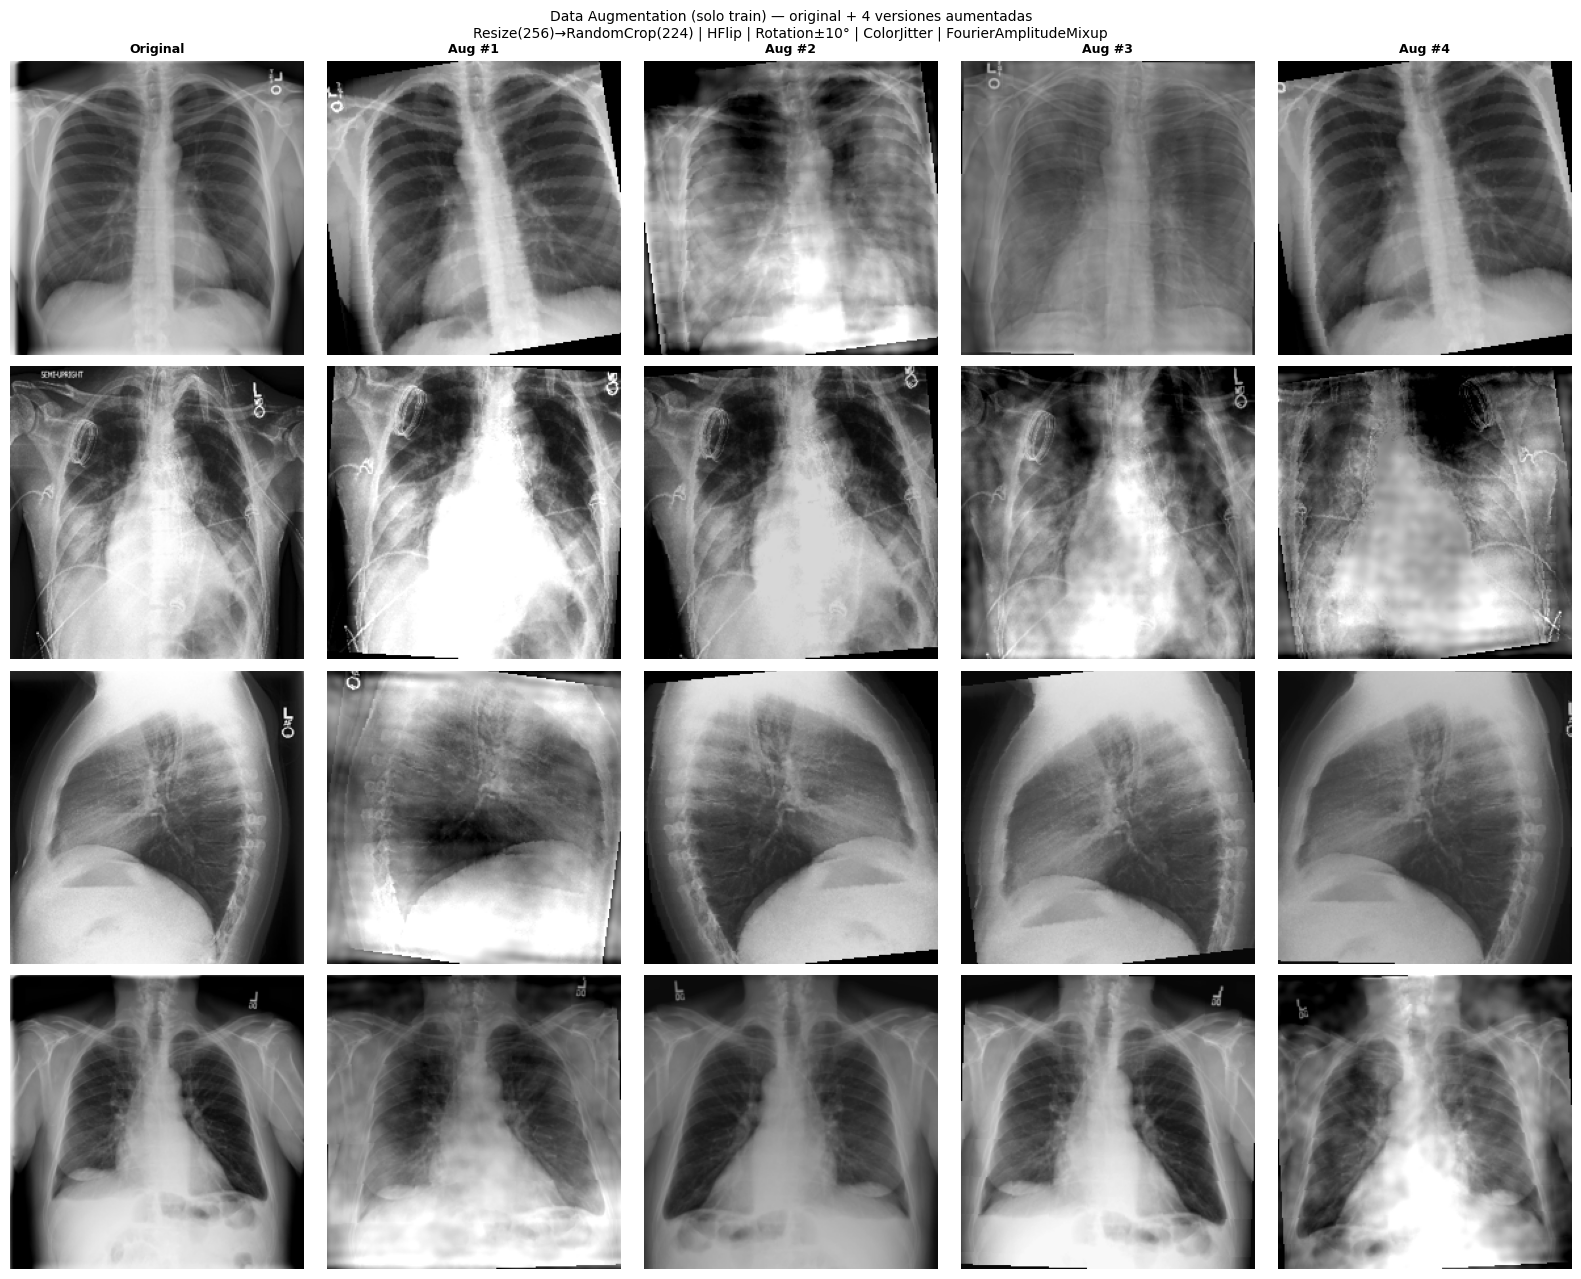

In [10]:
# Visualización: 4 imágenes × original + 4 versiones aumentadas
# (sin normalización para que sean visualmente interpretables)
aug_vis_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    fourier_mixup,
])

sample_rows = splits["train"].sample(4, random_state=SEED)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle(
    "Data Augmentation (solo train) — original + 4 versiones aumentadas\n"
    "Resize(256)→RandomCrop(224) | HFlip | Rotation±10° | ColorJitter | FourierAmplitudeMixup",
    fontsize=10,
)
col_titles = ["Original", "Aug #1", "Aug #2", "Aug #3", "Aug #4"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=9, fontweight="bold")

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    img_path = os.path.join(DATASET_ROOT, row["image_path"])
    original = Image.open(img_path).convert("RGB").resize((224, 224))

    axes[row_idx, 0].imshow(original, cmap="gray")
    active = [l for l in CANONICAL_LABELS if row.get(l) == 1.0]
    axes[row_idx, 0].set_xlabel(", ".join(active) if active else "No Finding",
                                fontsize=6, labelpad=2)
    axes[row_idx, 0].axis("off")

    for aug_idx in range(1, 5):
        aug_img = aug_vis_transform(Image.open(img_path).convert("RGB"))
        axes[row_idx, aug_idx].imshow(aug_img, cmap="gray")
        axes[row_idx, aug_idx].axis("off")

plt.tight_layout()
plt.show()

---
## (e) Verificación final

DataLoaders finales con todos los transforms aplicados.

In [ ]:
# ── Datasets finales con transforms ────────────────────────────────────────
train_ds = ChestXRayDataset(
    os.path.join(DATA_DIR, "train.csv"), DATASET_ROOT, transform=train_transform)
val_ds = ChestXRayDataset(
    os.path.join(DATA_DIR, "val.csv"),   DATASET_ROOT, transform=val_test_transform)
test_int_ds = ChestXRayDataset(
    os.path.join(DATA_DIR, "test_interno.csv"), DATASET_ROOT, transform=val_test_transform)
test_ext_ds = ChestXRayDataset(
    os.path.join(DATA_DIR, "test_externo.csv"), DATASET_ROOT, transform=val_test_transform)

train_loader    = DataLoader(train_ds,    batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_int_loader = DataLoader(test_int_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_ext_loader = DataLoader(test_ext_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"{'Split':<14}  {'Imágenes':>10}  {'Batches':>8}  {'Shuffle':>7}  Transform")
print("-" * 65)
print(f"{'train':<14}  {len(train_ds):>10,}  {len(train_loader):>8,}  {'True':>7}  train_transform (+ aug)")
print(f"{'val':<14}  {len(val_ds):>10,}  {len(val_loader):>8,}  {'False':>7}  val_test_transform")
print(f"{'test_interno':<14}  {len(test_int_ds):>10,}  {len(test_int_loader):>8,}  {'False':>7}  val_test_transform")
print(f"{'test_externo':<14}  {len(test_ext_ds):>10,}  {len(test_ext_loader):>8,}  {'False':>7}  val_test_transform")

Split             Imágenes   Batches  Shuffle  Transform
-----------------------------------------------------------------
train              264,275     8,259     True  train_transform (+ aug)
val                 45,663     1,427    False  val_test_transform
test_interno        25,596       800    False  val_test_transform
test_externo        15,000       469    False  val_test_transform


In [12]:
# Tomar un batch del train_loader y verificar shapes y rangos
imgs, labels = next(iter(train_loader))

print(f"Tensor imágenes:  {imgs.shape}   (batch_size, canales, alto, ancho)")
print(f"Tensor labels:    {labels.shape}  (batch_size, num_clases)")
print(f"dtype imágenes:   {imgs.dtype}")
print(f"dtype labels:     {labels.dtype}")
print(f"Rango normalizado: [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"  (esperado ≈ [-2.2, 2.7] con normalización ImageNet)")
print(f"Valores únicos en labels: {sorted(labels.unique().tolist())}")

e:\dataset\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tensor imágenes:  torch.Size([32, 3, 224, 224])   (batch_size, canales, alto, ancho)
Tensor labels:    torch.Size([32, 11])  (batch_size, num_clases)
dtype imágenes:   torch.float32
dtype labels:     torch.float32
Rango normalizado: [-2.118, 2.640]
  (esperado ≈ [-2.2, 2.7] con normalización ImageNet)
Valores únicos en labels: [0.0, 1.0]


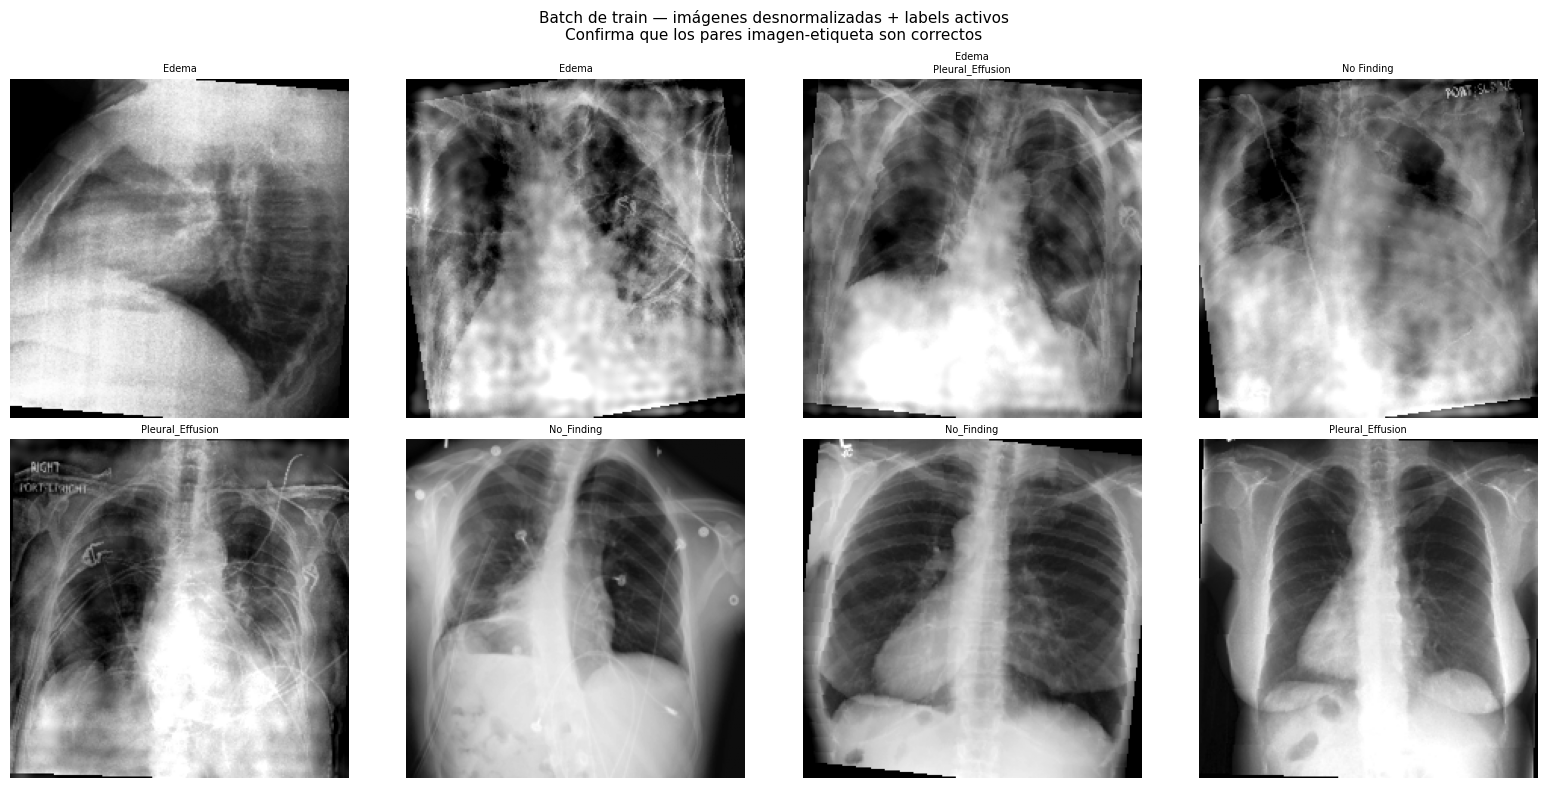

Verificación completa: pares imagen-etiqueta correctos.


In [13]:
# Visualizar 8 imágenes desnormalizadas con sus labels activos
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
imgs_denorm = (imgs * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    "Batch de train — imágenes desnormalizadas + labels activos\n"
    "Confirma que los pares imagen-etiqueta son correctos",
    fontsize=11,
)
for i, ax in enumerate(axes.flat):
    img_np = imgs_denorm[i].permute(1, 2, 0).numpy()
    ax.imshow(img_np.mean(axis=2), cmap="gray")
    active = [CANONICAL_LABELS[j] for j, v in enumerate(labels[i]) if v == 1.0]
    label_str = "\n".join(active) if active else "No Finding"
    ax.set_title(label_str, fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Verificación completa: pares imagen-etiqueta correctos.")